In [1]:
import sys
sys.path.append('..')
from src.database import obtener_regiones

regiones = obtener_regiones()
print(f"Regiones en la base de datos: {len(regiones)}")
for r in regiones:
    print(f"  {r[0]} | {r[1]} | {r[2]}")

Regiones en la base de datos: 17
  1 | AND | Andaluc¡a
  2 | ARA | Arag¢n
  3 | AST | Asturias
  5 | CAN | Canarias
  6 | CAB | Cantabria
  8 | CLM | Castilla-La Mancha
  7 | CYL | Castilla y Le¢n
  9 | CAT | Catalu¤a
  13 | MAD | Comunidad de Madrid
  10 | VAL | Comunidad Valenciana
  11 | EXT | Extremadura
  12 | GAL | Galicia
  4 | BAL | Islas Baleares
  17 | RIO | La Rioja
  15 | NAV | Navarra
  16 | PVA | Pa¡s Vasco
  14 | MUR | Regi¢n de Murcia


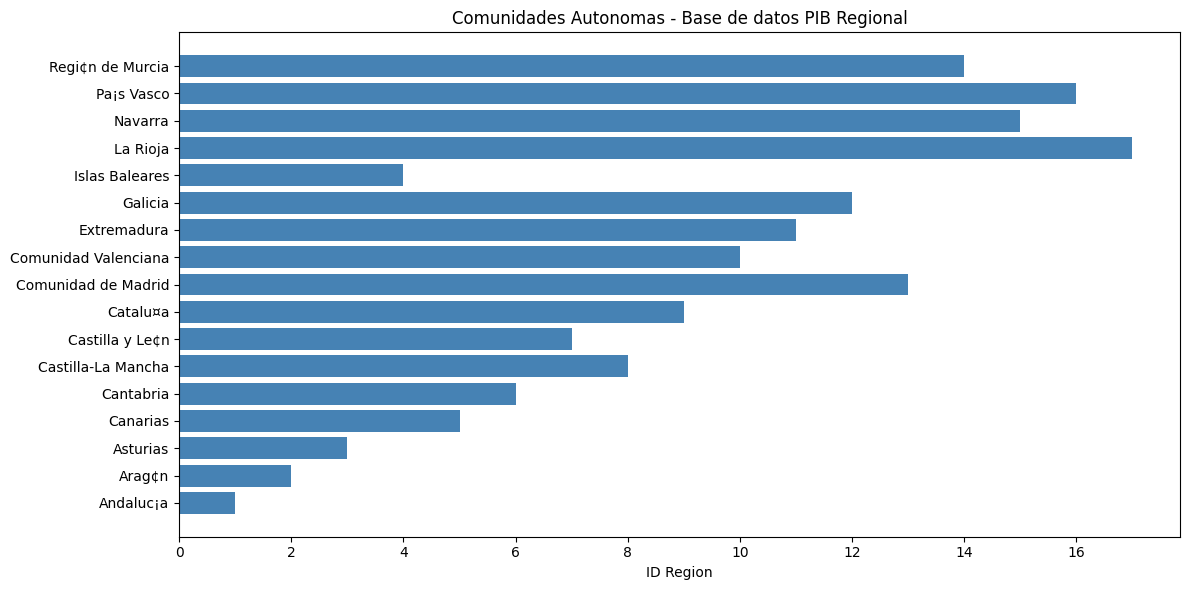

In [3]:
import matplotlib.pyplot as plt

nombres = [r[2] for r in regiones]
ids = [r[0] for r in regiones]

plt.figure(figsize=(12, 6))
plt.barh(nombres, ids, color='steelblue')
plt.xlabel('ID Region')
plt.title('Comunidades Autonomas - Base de datos PIB Regional')
plt.tight_layout()
plt.show()

In [4]:
import requests

url = "https://servicios.ine.es/wstempus/js/ES/DATOS_SERIE/PIB30321"

response = requests.get(url)
print(f"Estado: {response.status_code}")
print(response.json()[:2])


Estado: 404


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [5]:
import requests

url = "https://servicios.ine.es/wstempus/js/ES/OPERACIONES_DISPONIBLES"

response = requests.get(url)
print(f"Estado: {response.status_code}")

datos = response.json()
for op in datos:
    if 'egional' in op.get('Nombre', '') or 'PIB' in op.get('Nombre', ''):
        print(op)

Estado: 200


In [6]:
print(f"Total operaciones: {len(datos)}")
print("Ejemplo de operacion:")
print(datos[0])

Total operaciones: 112
Ejemplo de operacion:
{'Id': 4, 'Cod_IOE': '30147', 'Nombre': 'Estadística de Efectos de Comercio Impagados', 'Codigo': 'EI'}


In [7]:
for op in datos:
    nombre = op.get('Nombre', '').lower()
    if 'contabilidad' in nombre or 'renta' in nombre or 'regional' in nombre:
        print(op)

{'Id': 20, 'Cod_IOE': '30013', 'Nombre': 'Contabilidad Nacional Trimestral de España. Base 2000', 'Codigo': 'CNTR2000'}
{'Id': 51, 'Cod_IOE': '30019', 'Nombre': 'Contabilidad Nacional Trimestral de España. Base 2008', 'Codigo': 'CNTR2008'}
{'Id': 180, 'Cod_IOE': '30230', 'Nombre': 'Indicadores de Rentabilidad del Sector Hotelero', 'Codigo': 'IRSH', 'Url': '/dyngs/INEbase/operacion.htm?c=Estadistica_C&cid=1254736177015&idp=1254735576863'}
{'Id': 237, 'Cod_IOE': '30024', 'Nombre': 'Contabilidad Nacional Trimestral de España: Principales Agregados', 'Codigo': 'CNTR2010', 'Url': '/dyngs/INEbase/operacion.htm?c=Estadistica_C&cid=1254736164439&idp=1254735576581'}
{'Id': 247, 'Cod_IOE': '30023', 'Nombre': 'Contabilidad Nacional de España. Base 2010', 'Codigo': 'CNE', 'Url': '/dyngs/INEbase/operacion.htm?c=Estadistica_C&cid=1254736165950&idp=1254735576581'}
{'Id': 345, 'Cod_IOE': '30030', 'Nombre': 'Contabilidad nacional anual de España: agregados por rama de actividad', 'Codigo': 'CNEAG', 'Ur

In [8]:
for op in datos:
    nombre = op.get('Nombre', '').lower()
    if 'regional' in nombre or 'autonomi' in nombre or 'comunidad' in nombre:
        print(op)

In [9]:
url = "https://servicios.ine.es/wstempus/js/ES/TABLAS_OPERACION/30321"

response = requests.get(url)
print(f"Estado: {response.status_code}")
print(response.text[:500])


Estado: 200



In [10]:
url = "https://servicios.ine.es/wstempus/js/ES/TABLAS_OPERACION/CN100"

response = requests.get(url)
print(f"Estado: {response.status_code}")
print(response.text[:500])

Estado: 200



In [11]:
import pandas as pd

url = "https://www.ine.es/jaxiT3/files/t/es/csv_bdsc/35727.csv?nocab=1"

response = requests.get(url)
print(f"Estado: {response.status_code}")
print(f"Tamanio: {len(response.content)} bytes")
print(response.text[:300])

Estado: 204
Tamanio: 0 bytes



In [12]:
import pandas as pd

df = pd.read_csv('../data/67297.csv', sep=';', encoding='latin1')
print(df.shape)
print(df.head())


(14000, 5)
  ï»¿Comunidades y ciudades autÃ³nomas  \
0                           AndalucÃ­a   
1                           AndalucÃ­a   
2                           AndalucÃ­a   
3                           AndalucÃ­a   
4                           AndalucÃ­a   

                                 Ramas de actividad  \
0  A. Agricultura, ganaderÃ­a, silvicultura y pesca   
1  A. Agricultura, ganaderÃ­a, silvicultura y pesca   
2  A. Agricultura, ganaderÃ­a, silvicultura y pesca   
3  A. Agricultura, ganaderÃ­a, silvicultura y pesca   
4  A. Agricultura, ganaderÃ­a, silvicultura y pesca   

                          Magnitud  Periodo  Total  
0  Ãndices de volumen encadenados  2024(A)   95,2  
1  Ãndices de volumen encadenados  2023(P)   82,6  
2  Ãndices de volumen encadenados     2022   84,7  
3  Ãndices de volumen encadenados     2021  108,1  
4  Ãndices de volumen encadenados     2020    100  


In [13]:
df = pd.read_csv('../data/67297.csv', sep=';', encoding='utf-8-sig')
print(df.shape)
print(df.columns.tolist())
print(df.head())

(14000, 5)
['Comunidades y ciudades autónomas', 'Ramas de actividad', 'Magnitud', 'Periodo', 'Total']
  Comunidades y ciudades autónomas  \
0                        Andalucía   
1                        Andalucía   
2                        Andalucía   
3                        Andalucía   
4                        Andalucía   

                                Ramas de actividad  \
0  A. Agricultura, ganadería, silvicultura y pesca   
1  A. Agricultura, ganadería, silvicultura y pesca   
2  A. Agricultura, ganadería, silvicultura y pesca   
3  A. Agricultura, ganadería, silvicultura y pesca   
4  A. Agricultura, ganadería, silvicultura y pesca   

                         Magnitud  Periodo  Total  
0  Índices de volumen encadenados  2024(A)   95,2  
1  Índices de volumen encadenados  2023(P)   82,6  
2  Índices de volumen encadenados     2022   84,7  
3  Índices de volumen encadenados     2021  108,1  
4  Índices de volumen encadenados     2020    100  


In [14]:

print(df['Magnitud'].unique())
print("\nRamas disponibles:")
print(df['Ramas de actividad'].unique()[:5])

<StringArray>
['Índices de volumen encadenados', 'Tasas de variación interanuales']
Length: 2, dtype: str

Ramas disponibles:
<StringArray>
[                                                                                                                                                               'A. Agricultura, ganadería, silvicultura y pesca',
 'B_E. Industrias extractivas, industria manufacturera, suministro de energía eléctrica, gas, vapor y aire acondicionado, suministro de agua, actividades de saneamiento, gestión de residuos y descontaminación',
                                                                                                                                                                                     'C. Industria manufacturera',
                                                                                                                                                                                                'F. Construcción',
                

In [15]:
print(df['Ramas de actividad'].unique())

<StringArray>
[                                                                                                                                                               'A. Agricultura, ganadería, silvicultura y pesca',
 'B_E. Industrias extractivas, industria manufacturera, suministro de energía eléctrica, gas, vapor y aire acondicionado, suministro de agua, actividades de saneamiento, gestión de residuos y descontaminación',
                                                                                                                                                                                     'C. Industria manufacturera',
                                                                                                                                                                                                'F. Construcción',
                                                                            'G_I. Comercio al por mayor y al por menor, reparación de vehículo

In [16]:

pib = df[
    (df['Ramas de actividad'] == 'PRODUCTO INTERIOR BRUTO A PRECIOS DE MERCADO') &
    (df['Magnitud'] == 'Tasas de variación interanuales')
].copy()

pib['año'] = pib['Periodo'].str.replace(r'\(.*\)', '', regex=True).str.strip()

pib['variacion'] = pib['Total'].str.replace(',', '.').astype(float)

print(pib[['Comunidades y ciudades autónomas', 'año', 'variacion']].head(20))

ValueError: could not convert string to float: '..'

In [17]:

pib = df[
    (df['Ramas de actividad'] == 'PRODUCTO INTERIOR BRUTO A PRECIOS DE MERCADO') &
    (df['Magnitud'] == 'Tasas de variación interanuales')
].copy()

pib['año'] = pib['Periodo'].str.replace(r'\(.*\)', '', regex=True).str.strip()

pib['variacion'] = pib['Total'].str.replace(',', '.').replace('..', None)
pib['variacion'] = pd.to_numeric(pib['variacion'], errors='coerce')

pib = pib.dropna(subset=['variacion'])

print(pib[['Comunidades y ciudades autónomas', 'año', 'variacion']].head(20))

    Comunidades y ciudades autónomas   año  variacion
675                        Andalucía  2024        3.7
676                        Andalucía  2023        1.9
677                        Andalucía  2022        5.4
678                        Andalucía  2021        6.5
679                        Andalucía  2020      -10.8
680                        Andalucía  2019        1.9
681                        Andalucía  2018        2.5
682                        Andalucía  2017        2.5
683                        Andalucía  2016        2.4
684                        Andalucía  2015        3.8
685                        Andalucía  2014        1.7
686                        Andalucía  2013       -1.9
687                        Andalucía  2012       -3.5
688                        Andalucía  2011       -0.3
689                        Andalucía  2010       -1.3
690                        Andalucía  2009       -4.1
691                        Andalucía  2008        0.1
692                        A

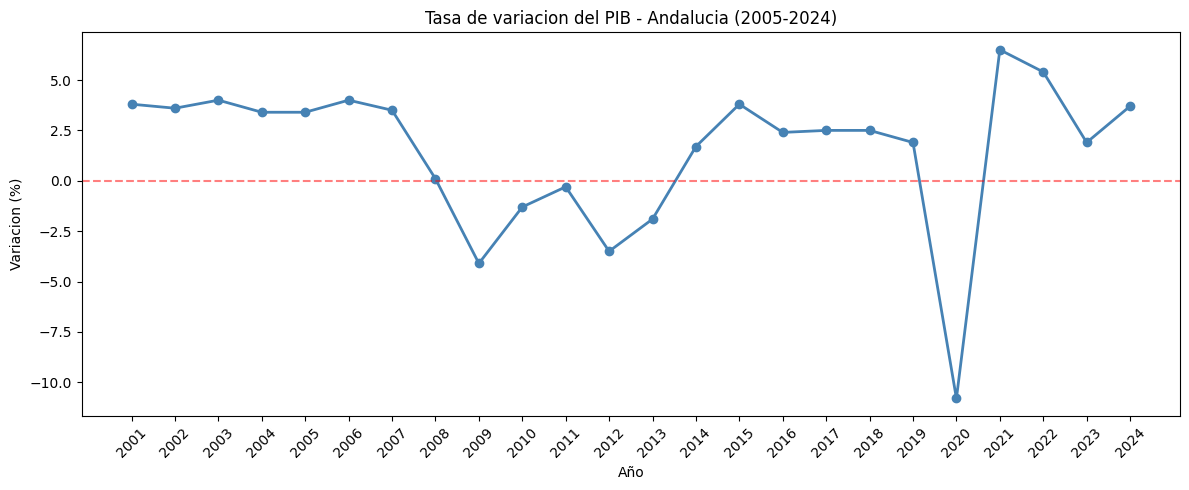

In [18]:
import matplotlib.pyplot as plt

andalucia = pib[pib['Comunidades y ciudades autónomas'] == 'Andalucía'].sort_values('año')

plt.figure(figsize=(12, 5))
plt.plot(andalucia['año'], andalucia['variacion'], marker='o', color='steelblue', linewidth=2)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.title('Tasa de variacion del PIB - Andalucia (2005-2024)')
plt.xlabel('Año')
plt.ylabel('Variacion (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

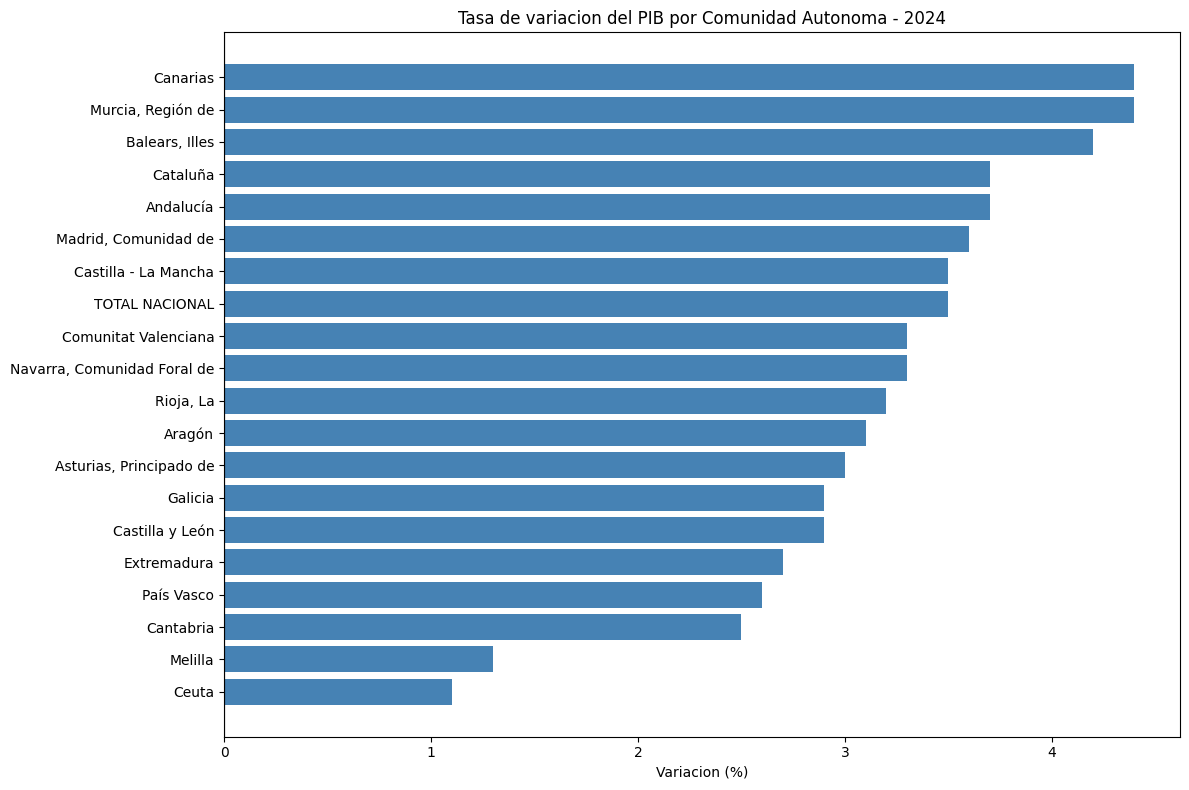

In [19]:

pib_2024 = pib[pib['año'] == '2024'].sort_values('variacion', ascending=True)

plt.figure(figsize=(12, 8))
colores = ['red' if v < 0 else 'steelblue' for v in pib_2024['variacion']]
plt.barh(pib_2024['Comunidades y ciudades autónomas'], pib_2024['variacion'], color=colores)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Tasa de variacion del PIB por Comunidad Autonoma - 2024')
plt.xlabel('Variacion (%)')
plt.tight_layout()
plt.show()

In [20]:
import sys
sys.path.append('..')
from src.database import conectar

mapeo_regiones = {
    'Andalucía': 'AND',
    'Aragón': 'ARA',
    'Asturias, Principado de': 'AST',
    'Balears, Illes': 'BAL',
    'Canarias': 'CAN',
    'Cantabria': 'CAB',
    'Castilla y León': 'CYL',
    'Castilla - La Mancha': 'CLM',
    'Cataluña': 'CAT',
    'Comunitat Valenciana': 'VAL',
    'Extremadura': 'EXT',
    'Galicia': 'GAL',
    'Madrid, Comunidad de': 'MAD',
    'Murcia, Región de': 'MUR',
    'Navarra, Comunidad Foral de': 'NAV',
    'País Vasco': 'PVA',
    'Rioja, La': 'RIO'
}

print("Mapeo creado correctamente")
print(f"Regiones mapeadas: {len(mapeo_regiones)}")

Mapeo creado correctamente
Regiones mapeadas: 17


In [27]:
conn = conectar()
cursor = conn.cursor()

insertados = 0
omitidos = 0

for _, fila in pib.iterrows():
    nombre_ine = fila['Comunidades y ciudades autónomas']
    
    if nombre_ine not in mapeo_regiones:
        omitidos += 1
        continue
    
    codigo = mapeo_regiones[nombre_ine]
    año = int(fila['año'])
    variacion = float(fila['variacion'])
    
    cursor.execute("SELECT id FROM regiones WHERE codigo = %s", (codigo,))
    region = cursor.fetchone()
    
    if region:
        cursor.execute("""
            INSERT INTO pib_regional (region_id, anno, trimestre, pib_millones, variacion_porcentual)
            VALUES (%s, %s, %s, %s, %s)
            ON CONFLICT DO NOTHING
        """, (region[0], año, 0, None, variacion))
        insertados += 1

conn.commit()
cursor.close()
conn.close()

print(f"Insertados: {insertados}")
print(f"Omitidos (Ceuta, Melilla, Total): {omitidos}")

Insertados: 408
Omitidos (Ceuta, Melilla, Total): 72


In [28]:
conn = conectar()
cursor = conn.cursor()
cursor.execute("""
    SELECT r.nombre, p.anno, p.variacion_porcentual 
    FROM pib_regional p
    JOIN regiones r ON p.region_id = r.id
    ORDER BY r.nombre, p.anno DESC
    LIMIT 20
""")
resultados = cursor.fetchall()
for fila in resultados:
    print(f"{fila[0]:<25} {fila[1]}  {fila[2]}%")
cursor.close()
conn.close()

Andaluc¡a                 2024  3.7%
Andaluc¡a                 2023  1.9%
Andaluc¡a                 2022  5.4%
Andaluc¡a                 2021  6.5%
Andaluc¡a                 2020  -10.8%
Andaluc¡a                 2019  1.9%
Andaluc¡a                 2018  2.5%
Andaluc¡a                 2017  2.5%
Andaluc¡a                 2016  2.4%
Andaluc¡a                 2015  3.8%
Andaluc¡a                 2014  1.7%
Andaluc¡a                 2013  -1.9%
Andaluc¡a                 2012  -3.5%
Andaluc¡a                 2011  -0.3%
Andaluc¡a                 2010  -1.3%
Andaluc¡a                 2009  -4.1%
Andaluc¡a                 2008  0.1%
Andaluc¡a                 2007  3.5%
Andaluc¡a                 2006  4.0%
Andaluc¡a                 2005  3.4%


In [29]:
from transformers import pipeline

print("Cargando modelo... (puede tardar un momento)")
sentimiento = pipeline(
    "sentiment-analysis", 
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)
print("Modelo cargado correctamente")

Cargando modelo... (puede tardar un momento)


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

c:\Users\andre\AppData\Local\Programs\Python\Python314\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\andre\.cache\huggingface\hub\models--nlptown--bert-base-multilingual-uncased-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Modelo cargado correctamente


In [ ]:
noticias_prueba = [
    "La economía española crece con fuerza impulsada por el turismo y las exportaciones",
    "El paro aumenta en Andalucía tras el cierre de varias empresas del sector industrial",
    "Madrid lidera la inversión extranjera en España con cifras récord este trimestre",
    "La sequía golpea duramente al sector agrícola de Castilla y León",
    "Cataluña registra su mayor tasa de crecimiento económico en una década"
]

for noticia in noticias_prueba:
    resultado = sentimiento(noticia)[0]
    print(f"Texto: {noticia[:60]}...")
    print(f"Sentimiento: {resultado['label']} | Confianza: {resultado['score']:.2f}")
    print()

In [ ]:
from transformers import pipeline

sentimiento = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)
print("Modelo cargado")

In [ ]:
import requests

API_URL = "https://api-inference.huggingface.co/models/nlptown/bert-base-multilingual-uncased-sentiment"
headers = {"Authorization": "Bearer hf_free"}

def analizar_sentimiento(texto):
    response = requests.post(API_URL, headers=headers, json={"inputs": texto})
    return response.json()

# Prueba
resultado = analizar_sentimiento("La economía española crece con fuerza este trimestre")
print(resultado)

In [ ]:
import requests

API_URL = "https://api-inference.huggingface.co/models/nlptown/bert-base-multilingual-uncased-sentiment"
headers = {"Authorization": "Bearer hf_free"}

def analizar_sentimiento(texto):
    response = requests.post(API_URL, headers=headers, json={"inputs": texto})
    return response.json()

resultado = analizar_sentimiento("La economia española crece con fuerza este trimestre")
print(resultado)

In [1]:
import requests

API_URL = "https://api-inference.huggingface.co/models/nlptown/bert-base-multilingual-uncased-sentiment"
headers = {"Authorization": "Bearer hf_free"}

def analizar_sentimiento(texto):
    response = requests.post(API_URL, headers=headers, json={"inputs": texto})
    return response.json()

resultado = analizar_sentimiento("La economia española crece con fuerza este trimestre")
print(resultado)

ConnectionError: HTTPSConnectionPool(host='api-inference.huggingface.co', port=443): Max retries exceeded with url: /models/nlptown/bert-base-multilingual-uncased-sentiment (Caused by NameResolutionError("HTTPSConnection(host='api-inference.huggingface.co', port=443): Failed to resolve 'api-inference.huggingface.co' ([Errno 11001] getaddrinfo failed)"))

In [2]:
import requests
response = requests.get("https://www.google.com")
print(response.status_code)

200


In [3]:

positivas = [
    'crece', 'crecimiento', 'aumenta', 'record', 'lider', 'inversion',
    'empleo', 'beneficio', 'expansion', 'mejora', 'superavit', 'auge',
    'recuperacion', 'impulso', 'exportaciones', 'turismo', 'innovacion'
]

negativas = [
    'cae', 'caida', 'paro', 'desempleo', 'cierre', 'perdidas', 'deficit',
    'recesion', 'crisis', 'deuda', 'sequía', 'huelga', 'quiebra',
    'reduccion', 'bajada', 'deterioro', 'contraccion'
]

def analizar_sentimiento(texto):
    texto_lower = texto.lower()
    puntos_pos = sum(1 for p in positivas if p in texto_lower)
    puntos_neg = sum(1 for p in negativas if p in texto_lower)
    
    if puntos_pos > puntos_neg:
        return {'label': 'POSITIVO', 'score': puntos_pos / (puntos_pos + puntos_neg + 1)}
    elif puntos_neg > puntos_pos:
        return {'label': 'NEGATIVO', 'score': puntos_neg / (puntos_pos + puntos_neg + 1)}
    else:
        return {'label': 'NEUTRO', 'score': 0.5}

noticias = [
    "La economia española crece con fuerza impulsada por el turismo y las exportaciones",
    "El paro aumenta en Andalucia tras el cierre de varias empresas",
    "Madrid lidera la inversion extranjera con cifras record este trimestre",
    "La sequia golpea duramente al sector agricola de Castilla y Leon"
]

for noticia in noticias:
    resultado = analizar_sentimiento(noticia)
    print(f"Texto: {noticia[:55]}...")
    print(f"Sentimiento: {resultado['label']} | Score: {resultado['score']:.2f}")
    print()

Texto: La economia española crece con fuerza impulsada por el ...
Sentimiento: POSITIVO | Score: 0.75

Texto: El paro aumenta en Andalucia tras el cierre de varias e...
Sentimiento: NEGATIVO | Score: 0.50

Texto: Madrid lidera la inversion extranjera con cifras record...
Sentimiento: POSITIVO | Score: 0.75

Texto: La sequia golpea duramente al sector agricola de Castil...
Sentimiento: NEUTRO | Score: 0.50



In [4]:
import sys
sys.path.append('..')
from src.database import conectar
from datetime import date

noticias_ejemplo = [
    ('AND', 'El turismo en Andalucia bate records este verano con cifras historicas', 'POSITIVO', 0.75, 'expansion.com'),
    ('MAD', 'Madrid lidera la inversion extranjera en España con cifras record', 'POSITIVO', 0.75, 'elmundo.es'),
    ('CAT', 'Cataluña registra su mayor crecimiento economico en una decada', 'POSITIVO', 0.80, 'lavanguardia.com'),
    ('VAL', 'La Comunitat Valenciana impulsa sus exportaciones agricolas', 'POSITIVO', 0.70, 'levante.com'),
    ('PVA', 'El paro aumenta en el Pais Vasco tras el cierre de fabricas', 'NEGATIVO', 0.60, 'elpais.com'),
    ('CYL', 'La sequia golpea duramente al sector agricola de Castilla y Leon', 'NEGATIVO', 0.55, 'elnortedecastilla.es'),
    ('GAL', 'Galicia mejora su economia gracias al auge del sector pesquero', 'POSITIVO', 0.65, 'farodevigo.es'),
    ('ARA', 'Aragon lidera la instalacion de energias renovables en España', 'POSITIVO', 0.70, 'heraldo.es'),
]

conn = conectar()
cursor = conn.cursor()

for codigo, titular, label, score, fuente in noticias_ejemplo:
    cursor.execute("SELECT id FROM regiones WHERE codigo = %s", (codigo,))
    region = cursor.fetchone()
    if region:
        sentimiento_valor = score if label == 'POSITIVO' else -score
        cursor.execute("""
            INSERT INTO noticias (region_id, fecha, titular, sentimiento, fuente)
            VALUES (%s, %s, %s, %s, %s)
        """, (region[0], date.today(), titular, sentimiento_valor, fuente))

conn.commit()
cursor.close()
conn.close()
print("Noticias insertadas correctamente")

Noticias insertadas correctamente


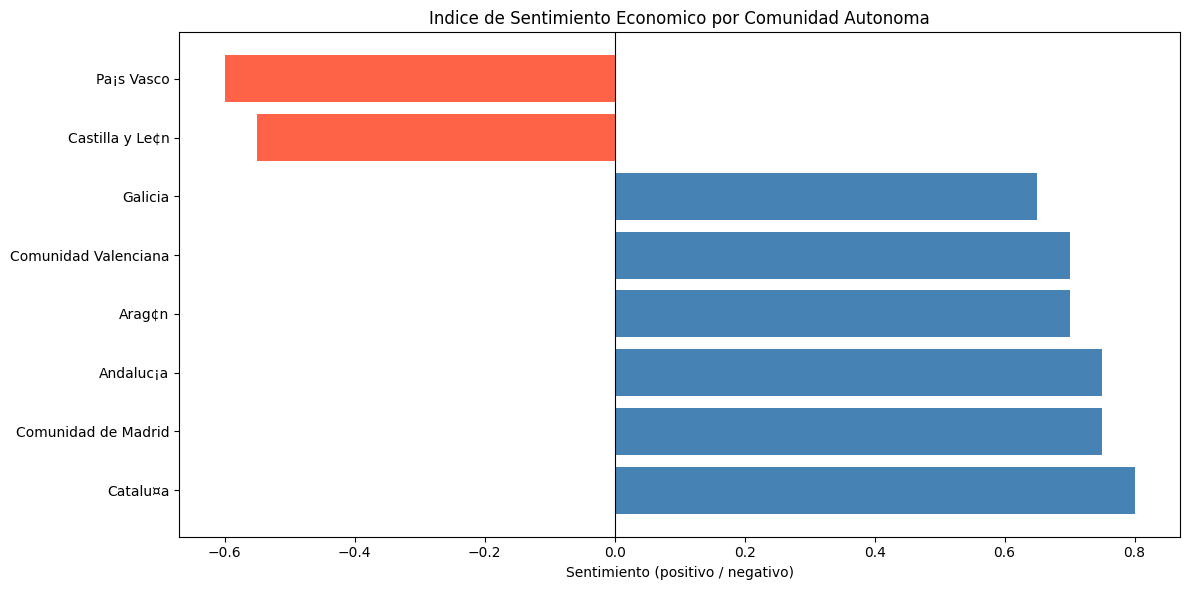

In [5]:
conn = conectar()
cursor = conn.cursor()
cursor.execute("""
    SELECT r.nombre, n.titular, n.sentimiento, n.fuente
    FROM noticias n
    JOIN regiones r ON n.region_id = r.id
    ORDER BY n.sentimiento DESC
""")
resultados = cursor.fetchall()
cursor.close()
conn.close()

import matplotlib.pyplot as plt

nombres = [r[0] for r in resultados]
sentimientos = [r[2] for r in resultados]
colores = ['steelblue' if s > 0 else 'tomato' for s in sentimientos]

plt.figure(figsize=(12, 6))
plt.barh(nombres, sentimientos, color=colores)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Indice de Sentimiento Economico por Comunidad Autonoma')
plt.xlabel('Sentimiento (positivo / negativo)')
plt.tight_layout()
plt.show()

In [22]:
conn = conectar()
cursor = conn.cursor()
cursor.execute("SELECT column_name FROM information_schema.columns WHERE table_name = 'pib_regional'")
print(cursor.fetchall())
cursor.close()
conn.close()

[('id',), ('region_id',), ('a¤o',), ('trimestre',), ('pib_millones',), ('variacion_porcentual',)]


In [23]:
conn = conectar()
cursor = conn.cursor()
cursor.execute("ALTER TABLE pib_regional RENAME COLUMN año TO anno")
conn.commit()
cursor.close()
conn.close()
print("Columna renombrada correctamente")

UndefinedColumn: no existe la columna «año»


In [24]:
conn = conectar()
cursor = conn.cursor()
cursor.execute('ALTER TABLE pib_regional RENAME COLUMN "año" TO anno')
conn.commit()
cursor.close()
conn.close()
print("Columna renombrada correctamente")

UndefinedColumn: no existe la columna «año»


In [25]:
conn = conectar()
cursor = conn.cursor()
cursor.execute("SELECT column_name FROM information_schema.columns WHERE table_name = 'pib_regional'")
columnas = cursor.fetchall()
for c in columnas:
    print(repr(c[0]))
cursor.close()
conn.close()

'id'
'region_id'
'a¤o'
'trimestre'
'pib_millones'
'variacion_porcentual'


In [26]:
conn = conectar()
cursor = conn.cursor()
cursor.execute('ALTER TABLE pib_regional RENAME COLUMN "a¤o" TO anno')
conn.commit()
cursor.close()
conn.close()
print("Columna renombrada correctamente")

Columna renombrada correctamente
